# Model Training and Validation

This notebook trains multiple machine learning models to predict customer default risk using behavioral features.

The notebook includes:

- Logistic Regression
- Random Forest
- XGBoost
- CatBoost
- Hyperparameter tuning using RandomizedSearchCV
- 5-Fold Stratified Cross Validation
- Probability Calibration using CalibratedClassifierCV
- ROC-AUC comparison
- Precision, Recall and F1 comparison
- ROC Curve
- Precision-Recall Curve
- Threshold Optimization
- Cost Optimization
- Feature Importance Analysis
- Saving trained models

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/Credit_Risk_Project/data/behavioral_features.csv"

df = pd.read_csv(path)

print(df.shape)

df.head()

(30000, 31)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,default,pay_delay_trend,pay_delay_volatility,pay_trend,recency_weighted_stress,bill_payment_ratio,avg_utilization
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,1,0.914286,1.861899,4,4.5,11.084892,0.064200
1,2,120000,2,2,2,26,-1,2,0,0,...,1000,0,2000,1,-0.257143,1.224745,-3,4.0,3.411306,0.023718
2,3,90000,2,2,2,34,0,0,0,0,...,1000,1000,5000,0,0.000000,0.000000,0,0.0,9.221063,0.188246
3,4,50000,2,2,1,37,0,0,0,0,...,1100,1069,1000,0,0.000000,0.000000,0,0.0,27.559447,0.771113
4,5,50000,1,2,1,57,-1,0,-1,0,...,9000,689,679,0,-0.171429,0.516398,-1,-6.5,1.851477,0.364463


In [ ]:
df = df.apply(pd.to_numeric)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       30000 non-null  int64  
 1   LIMIT_BAL                30000 non-null  int64  
 2   SEX                      30000 non-null  int64  
 3   EDUCATION                30000 non-null  int64  
 4   MARRIAGE                 30000 non-null  int64  
 5   AGE                      30000 non-null  int64  
 6   PAY_0                    30000 non-null  int64  
 7   PAY_2                    30000 non-null  int64  
 8   PAY_3                    30000 non-null  int64  
 9   PAY_4                    30000 non-null  int64  
 10  PAY_5                    30000 non-null  int64  
 11  PAY_6                    30000 non-null  int64  
 12  BILL_AMT1                30000 non-null  int64  
 13  BILL_AMT2                30000 non-null  int64  
 14  BILL_AMT3             

In [ ]:
print(df.shape)

display(df["default"].value_counts())

display(df["default"].value_counts(normalize=True))

(30000, 31)


,count
default,
0,23364
1,6636


,proportion
default,
0,0.7788
1,0.2212


In [ ]:
target = "default"

features = [

    col

    for col in df.columns

    if col not in ["ID", target]

]

X = df[features]

y = df[target]

print(X.shape)

print(y.shape)

(30000, 29)
(30000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(

    X,

    y,

    test_size=0.25,

    random_state=42,

    stratify=y

)

print("Training:", X_train.shape)

print("Validation:", X_val.shape)

Training: (22500, 29)
Validation: (7500, 29)


In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

In [ ]:
from sklearn.metrics import (

    roc_auc_score,

    roc_curve,

    precision_recall_curve,

    classification_report,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    auc

)

In [ ]:
from sklearn.model_selection import (

    RandomizedSearchCV,

    cross_val_score,

    cross_val_predict

)

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

In [ ]:
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

In [ ]:
!pip install -q xgboost

from xgboost import XGBClassifier

In [ ]:
!pip install -q catboost

from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.4 MB/s eta 0:00:00


In [ ]:
results = pd.DataFrame(

    columns=[

        "Model",

        "CV ROC-AUC",

        "Validation ROC-AUC",

        "Precision",

        "Recall",

        "F1"

    ]

)

results

,Model,CV ROC-AUC,Validation ROC-AUC,Precision,Recall,F1


In [ ]:
log_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        random_state=42,
        max_iter=5000,
        class_weight="balanced"
    ))
])

log_pipeline

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    random_state=42))])

In [ ]:
log_param_grid = {
    "lr__C": np.logspace(-2, 2, 10),
    "lr__penalty": ["l2"],
    "lr__solver": ["lbfgs"]
}

log_param_grid

{'lr__C': array([1.00000000e-02, 2.78255940e-02, 7.74263683e-02, 2.15443469e-01,
        5.99484250e-01, 1.66810054e+00, 4.64158883e+00, 1.29154967e+01,
        3.59381366e+01, 1.00000000e+02]),
 'lr__penalty': ['l2'],
 'lr__solver': ['lbfgs']}

In [ ]:
log_search = RandomizedSearchCV(
    estimator=log_pipeline,
    param_distributions=log_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

log_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('lr',
                                              LogisticRegression(class_weight='balanced',
                                                                 max_iter=5000,
                                                                 random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'lr__C': array([1.00000000e-02, 2.78255940e-02, 7.74263683e-02, 2.15443469e-01,
       5.99484250e-01, 1.66810054e+00, 4.64158883e+00, 1.29154967e+01,
       3.59381366e+01, 1.00000000e+02]),
                                        'lr__penalty': ['l2'],
                                        'lr__solver': ['lbfgs']},
                   random_state=42, scoring='roc_auc', verbose=1)

In [ ]:
print("=" * 60)
print("Best Logistic Regression Parameters")
print("=" * 60)

print(log_search.best_params_)

print("\nBest 5-Fold CV ROC-AUC: {:.4f}".format(log_search.best_score_))

best_log_model = log_search.best_estimator_

Best Logistic Regression Parameters
{'lr__solver': 'lbfgs', 'lr__penalty': 'l2', 'lr__C': np.float64(35.93813663804626)}

Best 5-Fold CV ROC-AUC: 0.7430


In [ ]:
log_calibrated = CalibratedClassifierCV(
    estimator=best_log_model,
    method="sigmoid",
    cv=cv
)

log_calibrated.fit(X_train, y_train)

CalibratedClassifierCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                                 ('lr',
                                                  LogisticRegression(C=np.float64(35.93813663804626),
                                                                     class_weight='balanced',
                                                                     max_iter=5000,
                                                                     random_state=42))]))

In [ ]:
log_val_probs = log_calibrated.predict_proba(X_val)[:, 1]
log_val_preds = log_calibrated.predict(X_val)

log_auc = roc_auc_score(y_val, log_val_probs)
log_precision = precision_score(y_val, log_val_preds)
log_recall = recall_score(y_val, log_val_preds)
log_f1 = f1_score(y_val, log_val_preds)

print("=" * 60)
print("Logistic Regression Performance")
print("=" * 60)
print(f"5-Fold CV ROC-AUC : {log_search.best_score_:.4f}")
print(f"Validation ROC-AUC: {log_auc:.4f}")
print(f"Precision         : {log_precision:.4f}")
print(f"Recall            : {log_recall:.4f}")
print(f"F1 Score          : {log_f1:.4f}")

results.loc[len(results)] = [
    "Logistic Regression",
    log_search.best_score_,
    log_auc,
    log_precision,
    log_recall,
    log_f1
]

results

Logistic Regression Performance
5-Fold CV ROC-AUC : 0.7430
Validation ROC-AUC: 0.7312
Precision         : 0.6501
Recall            : 0.2128
F1 Score          : 0.3206


,Model,CV ROC-AUC,Validation ROC-AUC,Precision,Recall,F1
0,Logistic Regression,0.743035,0.731224,0.650092,0.212779,0.320618


In [ ]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [ ]:
rf_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [2, 4, 8],
    "max_features": ["sqrt"],
    "bootstrap": [True]
}

In [ ]:
rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    refit=True
)

rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    n_jobs=-1,
                                                    random_state=42),
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [10, 15, 20],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [2, 4, 8],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 300, 500]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [ ]:
print("=" * 60)
print("Best Random Forest Parameters")
print("=" * 60)

print(rf_search.best_params_)

print("\nBest 5-Fold CV ROC-AUC: {:.4f}".format(rf_search.best_score_))

best_rf_model = rf_search.best_estimator_

print("\nBest Random Forest Model:")
print(best_rf_model)

Best Random Forest Parameters
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': True}

Best 5-Fold CV ROC-AUC: 0.7839

Best Random Forest Model:
RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=8, min_samples_split=5,
                       n_estimators=300, n_jobs=-1, random_state=42)


In [ ]:
rf_calibrated = CalibratedClassifierCV(
    estimator=best_rf_model,
    method="sigmoid",
    cv=cv
)

rf_calibrated.fit(X_train, y_train)

CalibratedClassifierCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=RandomForestClassifier(class_weight='balanced',
                                                        max_depth=10,
                                                        min_samples_leaf=8,
                                                        min_samples_split=5,
                                                        n_estimators=300,
                                                        n_jobs=-1,
                                                        random_state=42))

In [ ]:
rf_val_probs = rf_calibrated.predict_proba(X_val)[:, 1]
rf_val_preds = rf_calibrated.predict(X_val)

rf_auc = roc_auc_score(y_val, rf_val_probs)
rf_precision = precision_score(y_val, rf_val_preds)
rf_recall = recall_score(y_val, rf_val_preds)
rf_f1 = f1_score(y_val, rf_val_preds)

print("=" * 60)
print("Random Forest Performance")
print("=" * 60)
print(f"5-Fold CV ROC-AUC : {rf_search.best_score_:.4f}")
print(f"Validation ROC-AUC: {rf_auc:.4f}")
print(f"Precision         : {rf_precision:.4f}")
print(f"Recall            : {rf_recall:.4f}")
print(f"F1 Score          : {rf_f1:.4f}")

# Store results
results.loc[len(results)] = [
    "Random Forest",
    rf_search.best_score_,
    rf_auc,
    rf_precision,
    rf_recall,
    rf_f1
]

results

Random Forest Performance
5-Fold CV ROC-AUC : 0.7839
Validation ROC-AUC: 0.7792
Precision         : 0.6445
Recall            : 0.3737
F1 Score          : 0.4731


,Model,CV ROC-AUC,Validation ROC-AUC,Precision,Recall,F1
0,Logistic Regression,0.743035,0.731224,0.650092,0.212779,0.320618
1,Random Forest,0.783905,0.779241,0.644491,0.373719,0.473102


In [ ]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
xgb_param_grid = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.02, 0.05, 0.1],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.5, 1, 2],
    "reg_alpha": [0, 0.1, 0.3, 0.5],
    "reg_lambda": [1, 2, 5]
}

xgb_param_grid

{'n_estimators': [200, 400, 600, 800, 1000],
 'max_depth': [3, 4, 5, 6, 8],
 'learning_rate': [0.01, 0.02, 0.05, 0.1],
 'min_child_weight': [1, 3, 5, 7],
 'subsample': [0.7, 0.8, 0.9, 1.0],
 'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
 'gamma': [0, 0.5, 1, 2],
 'reg_alpha': [0, 0.1, 0.3, 0.5],
 'reg_lambda': [1, 2, 5]}

In [ ]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    verbose=2,
    n_jobs=-1,
    refit=True
)

xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='auc',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow...
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.5, 1, 2],
                                        'learning_rate': [0.01, 0.02, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000],
                                        'reg_alpha': [0, 0.1, 0.3, 0.5],
                                        'reg_lambda': [1, 2, 5],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [ ]:
print("=" * 60)
print("Best XGBoost Parameters")
print("=" * 60)

print(xgb_search.best_params_)

print("\nBest 5-Fold CV ROC-AUC: {:.4f}".format(
    xgb_search.best_score_
))

best_xgb_model = xgb_search.best_estimator_

print("\nBest XGBoost Model:")
print(best_xgb_model)

Best XGBoost Parameters
{'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.02, 'gamma': 2, 'colsample_bytree': 0.6}

Best 5-Fold CV ROC-AUC: 0.7871

Best XGBoost Model:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=2, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.02, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, ...)


In [ ]:
xgb_calibrated = CalibratedClassifierCV(
    estimator=best_xgb_model,
    method="sigmoid",
    cv=cv
)

xgb_calibrated.fit(
    X_train,
    y_train
)

CalibratedClassifierCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=0.6,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=True,
                                               eval_metric='auc',
                                               feature_types=None,
                                               feature_weights=None, gamma=2,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.02, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=5,
                                               max_leaves=None,
                                               min_child_weight=5, missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=200, n_jobs=-1,
                                               num_parallel_tree=None, ...))

In [ ]:
xgb_val_probs = xgb_calibrated.predict_proba(X_val)[:, 1]
xgb_val_preds = xgb_calibrated.predict(X_val)

xgb_auc = roc_auc_score(
    y_val,
    xgb_val_probs
)

xgb_precision = precision_score(
    y_val,
    xgb_val_preds
)

xgb_recall = recall_score(
    y_val,
    xgb_val_preds
)

xgb_f1 = f1_score(
    y_val,
    xgb_val_preds
)

print("=" * 60)
print("XGBoost Performance")
print("=" * 60)

print(f"5-Fold CV ROC-AUC : {xgb_search.best_score_:.4f}")
print(f"Validation ROC-AUC: {xgb_auc:.4f}")
print(f"Precision         : {xgb_precision:.4f}")
print(f"Recall            : {xgb_recall:.4f}")
print(f"F1 Score          : {xgb_f1:.4f}")

results.loc[len(results)] = [
    "XGBoost",
    xgb_search.best_score_,
    xgb_auc,
    xgb_precision,
    xgb_recall,
    xgb_f1
]

results

XGBoost Performance
5-Fold CV ROC-AUC : 0.7871
Validation ROC-AUC: 0.7823
Precision         : 0.6696
Recall            : 0.3653
F1 Score          : 0.4727


,Model,CV ROC-AUC,Validation ROC-AUC,Precision,Recall,F1
0,Logistic Regression,0.743035,0.731224,0.650092,0.212779,0.320618
1,Random Forest,0.783905,0.779241,0.644491,0.373719,0.473102
2,XGBoost,0.787101,0.782307,0.669613,0.365280,0.472699


In [ ]:
cat_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0
)

cat_model

CatBoostClassifier(eval_metric='AUC', loss_function='Logloss', random_seed=42, verbose=0)

In [ ]:
cat_param_grid = {
    "iterations": [200, 400, 600, 800, 1000],
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "border_count": [32, 64, 128, 254],
    "bagging_temperature": [0, 1, 3, 5],
    "random_strength": [1, 2, 5, 10]
}

cat_param_grid

{'iterations': [200, 400, 600, 800, 1000],
 'depth': [4, 6, 8, 10],
 'learning_rate': [0.01, 0.03, 0.05, 0.1],
 'l2_leaf_reg': [1, 3, 5, 7, 9],
 'border_count': [32, 64, 128, 254],
 'bagging_temperature': [0, 1, 3, 5],
 'random_strength': [1, 2, 5, 10]}

In [ ]:
cat_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=cat_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    verbose=2,
    n_jobs=-1,
    refit=True
)

cat_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=CatBoostClassifier(eval_metric='AUC', loss_function='Logloss', random_seed=42, verbose=0),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bagging_temperature': [0, 1, 3, 5],
                                        'border_count': [32, 64, 128, 254],
                                        'depth': [4, 6, 8, 10],
                                        'iterations': [200, 400, 600, 800,
                                                       1000],
                                        'l2_leaf_reg': [1, 3, 5, 7, 9],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'random_strength': [1, 2, 5, 10]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [ ]:
print("=" * 60)
print("Best CatBoost Parameters")
print("=" * 60)

print(cat_search.best_params_)

print(f"\nBest 5-Fold CV ROC-AUC: {cat_search.best_score_:.4f}")

best_cat_model = cat_search.best_estimator_

print("\nBest CatBoost Model:")
print(best_cat_model)

Best CatBoost Parameters
{'random_strength': 2, 'learning_rate': 0.01, 'l2_leaf_reg': 7, 'iterations': 1000, 'depth': 6, 'border_count': 32, 'bagging_temperature': 0}

Best 5-Fold CV ROC-AUC: 0.7866

Best CatBoost Model:
CatBoostClassifier(bagging_temperature=0, border_count=32, depth=6, eval_metric='AUC', iterations=1000, l2_leaf_reg=7, learning_rate=0.01, loss_function='Logloss', random_seed=42, random_strength=2, verbose=0)


In [ ]:
cat_calibrated = CalibratedClassifierCV(
    estimator=best_cat_model,
    method="sigmoid",
    cv=cv
)

cat_calibrated.fit(
    X_train,
    y_train
)

CalibratedClassifierCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=CatBoostClassifier(bagging_temperature=0, border_count=32, depth=6, eval_metric='AUC', iterations=1000, l2_leaf_reg=7, learning_rate=0.01, loss_function='Logloss', random_seed=42, random_strength=2, verbose=0))

In [ ]:
cat_val_probs = cat_calibrated.predict_proba(X_val)[:, 1]
cat_val_preds = cat_calibrated.predict(X_val)

cat_auc = roc_auc_score(
    y_val,
    cat_val_probs
)

cat_precision = precision_score(
    y_val,
    cat_val_preds
)

cat_recall = recall_score(
    y_val,
    cat_val_preds
)

cat_f1 = f1_score(
    y_val,
    cat_val_preds
)

print("=" * 60)
print("CatBoost Performance")
print("=" * 60)

print(f"5-Fold CV ROC-AUC : {cat_search.best_score_:.4f}")
print(f"Validation ROC-AUC: {cat_auc:.4f}")
print(f"Precision         : {cat_precision:.4f}")
print(f"Recall            : {cat_recall:.4f}")
print(f"F1 Score          : {cat_f1:.4f}")

results.loc[len(results)] = [
    "CatBoost",
    cat_search.best_score_,
    cat_auc,
    cat_precision,
    cat_recall,
    cat_f1
]

results

CatBoost Performance
5-Fold CV ROC-AUC : 0.7866
Validation ROC-AUC: 0.7820
Precision         : 0.6591
Recall            : 0.3671
F1 Score          : 0.4715


,Model,CV ROC-AUC,Validation ROC-AUC,Precision,Recall,F1
0,Logistic Regression,0.743035,0.731224,0.650092,0.212779,0.320618
1,Random Forest,0.783905,0.779241,0.644491,0.373719,0.473102
2,XGBoost,0.787101,0.782307,0.669613,0.365280,0.472699
3,CatBoost,0.786575,0.781952,0.659091,0.367089,0.471545


In [ ]:
results = results.sort_values(
    by="Validation ROC-AUC",
    ascending=False
).reset_index(drop=True)

results.style.format({
    "CV ROC-AUC": "{:.4f}",
    "Validation ROC-AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}"
})

,Model,CV ROC-AUC,Validation ROC-AUC,Precision,Recall,F1
0,XGBoost,0.7871,0.7823,0.6696,0.3653,0.4727
1,CatBoost,0.7866,0.7820,0.6591,0.3671,0.4715
2,Random Forest,0.7839,0.7792,0.6445,0.3737,0.4731
3,Logistic Regression,0.7430,0.7312,0.6501,0.2128,0.3206


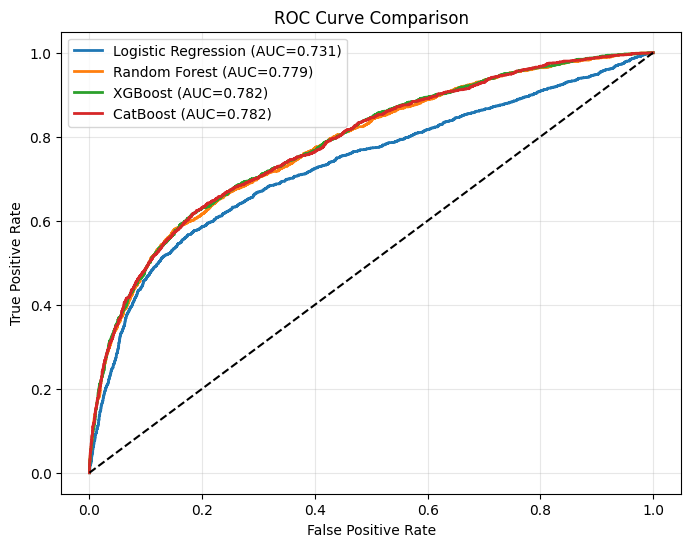

In [ ]:
plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": log_val_probs,
    "Random Forest": rf_val_probs,
    "XGBoost": xgb_val_probs,
    "CatBoost": cat_val_probs
}

for model_name, probs in models.items():

    fpr, tpr, _ = roc_curve(y_val, probs)

    auc_score = roc_auc_score(
        y_val,
        probs
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC={auc_score:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="black"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

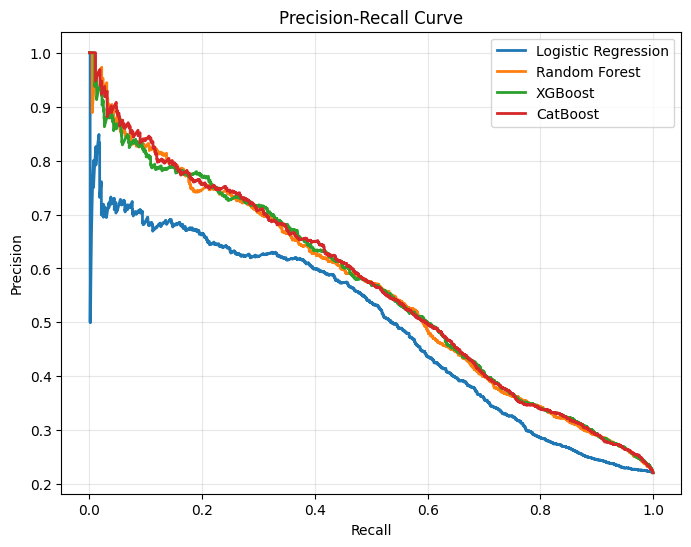

In [ ]:
plt.figure(figsize=(8,6))

for model_name, probs in models.items():

    precision, recall, _ = precision_recall_curve(
        y_val,
        probs
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=model_name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

Best Model: XGBoost
Optimal Threshold: 0.219
Best F1: 0.5477


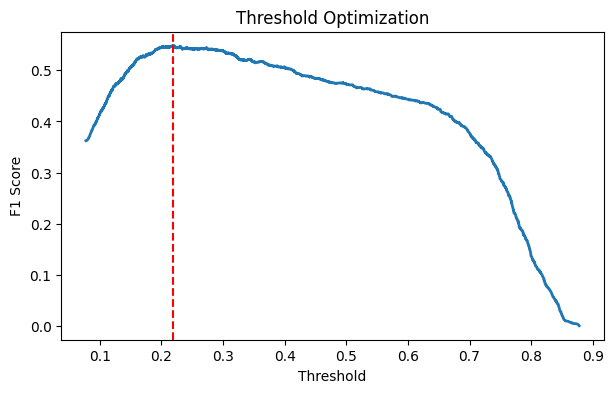

In [ ]:
best_model_name = results.iloc[0]["Model"]

probability_lookup = {
    "Logistic Regression": log_val_probs,
    "Random Forest": rf_val_probs,
    "XGBoost": xgb_val_probs,
    "CatBoost": cat_val_probs
}

best_probs = probability_lookup[best_model_name]

precision, recall, thresholds = precision_recall_curve(
    y_val,
    best_probs
)

f1_scores = (
    2 *
    precision[:-1] *
    recall[:-1]
) / (
    precision[:-1] +
    recall[:-1] +
    1e-10
)

best_idx = np.argmax(f1_scores)

optimal_threshold = thresholds[best_idx]

print("Best Model:", best_model_name)
print("Optimal Threshold:", round(optimal_threshold,3))
print("Best F1:", round(f1_scores[best_idx],4))

plt.figure(figsize=(7,4))

plt.plot(
    thresholds,
    f1_scores,
    linewidth=2
)

plt.axvline(
    optimal_threshold,
    color="red",
    linestyle="--"
)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")

plt.title("Threshold Optimization")

plt.show()

Best Cost Threshold: 0.1
Minimum Portfolio Cost: 51720


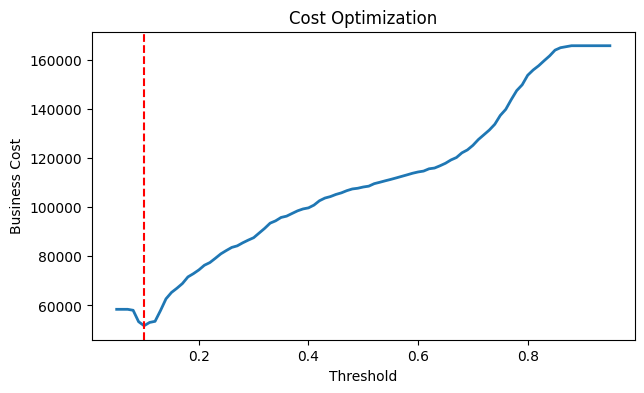

In [ ]:
cost_fn = 100
cost_fp = 10

threshold_grid = np.arange(
    0.05,
    0.96,
    0.01
)

costs = []

for threshold in threshold_grid:

    preds = (
        best_probs >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        preds
    ).ravel()

    cost = (
        fn * cost_fn +
        fp * cost_fp
    )

    costs.append(cost)

best_cost_idx = np.argmin(costs)

best_cost_threshold = threshold_grid[best_cost_idx]

print("Best Cost Threshold:", round(best_cost_threshold,2))
print("Minimum Portfolio Cost:", costs[best_cost_idx])

plt.figure(figsize=(7,4))

plt.plot(
    threshold_grid,
    costs,
    linewidth=2
)

plt.axvline(
    best_cost_threshold,
    color="red",
    linestyle="--"
)

plt.xlabel("Threshold")
plt.ylabel("Business Cost")

plt.title("Cost Optimization")

plt.show()

In [ ]:
print("=" * 80)
print("CLASSIFICATION REPORTS")
print("=" * 80)

for model_name, probs in probability_lookup.items():

    print("\n" + "=" * 80)
    print(f"{model_name} (Threshold = 0.50)")
    print("=" * 80)

    preds = (probs >= 0.50).astype(int)

    print(
        classification_report(
            y_val,
            preds,
            digits=4
        )
    )

print("\n" + "=" * 80)
print(f"{best_model_name} (F1 Optimized Threshold = {optimal_threshold:.3f})")
print("=" * 80)

best_preds_f1 = (
    best_probs >= optimal_threshold
).astype(int)

print(
    classification_report(
        y_val,
        best_preds_f1,
        digits=4
    )
)

print("\n" + "=" * 80)
print(f"{best_model_name} (Cost Optimized Threshold = {best_cost_threshold:.3f})")
print("=" * 80)

best_preds_cost = (
    best_probs >= best_cost_threshold
).astype(int)

print(
    classification_report(
        y_val,
        best_preds_cost,
        digits=4
    )
)

CLASSIFICATION REPORTS

Logistic Regression (Threshold = 0.50)
              precision    recall  f1-score   support

           0     0.8123    0.9675    0.8831      5841
           1     0.6501    0.2128    0.3206      1659

    accuracy                         0.8005      7500
   macro avg     0.7312    0.5901    0.6019      7500
weighted avg     0.7764    0.8005    0.7587      7500


Random Forest (Threshold = 0.50)
              precision    recall  f1-score   support

           0     0.8411    0.9414    0.8884      5841
           1     0.6445    0.3737    0.4731      1659

    accuracy                         0.8159      7500
   macro avg     0.7428    0.6576    0.6808      7500
weighted avg     0.7976    0.8159    0.7966      7500


XGBoost (Threshold = 0.50)
              precision    recall  f1-score   support

           0     0.8403    0.9488    0.8913      5841
           1     0.6696    0.3653    0.4727      1659

    accuracy                         0.8197      7500
   

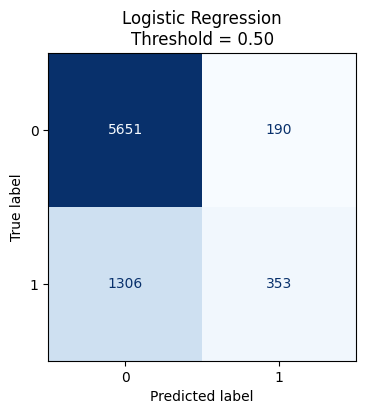

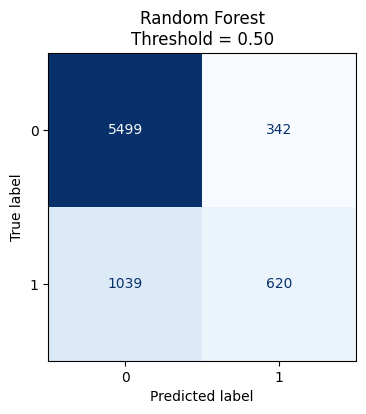

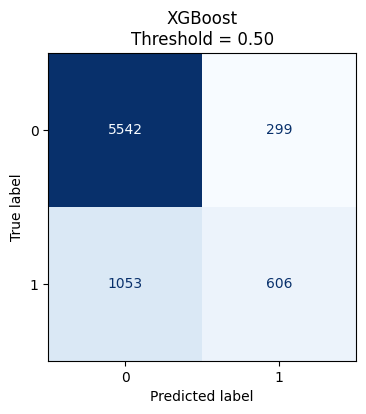

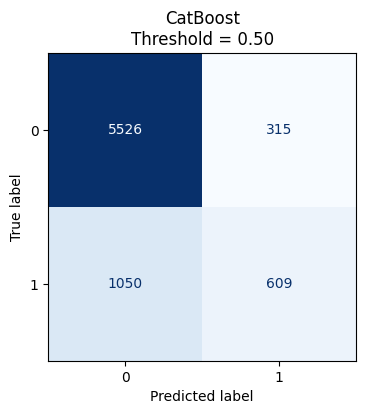

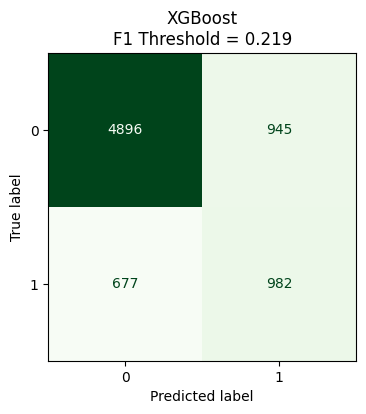

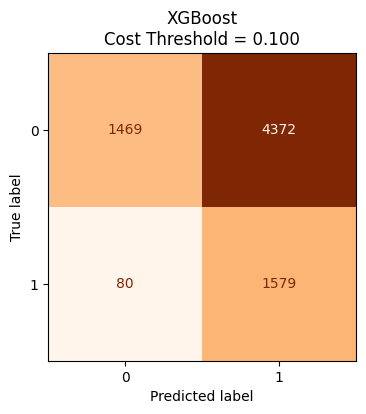

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

for model_name, probs in probability_lookup.items():

    preds = (
        probs >= 0.50
    ).astype(int)

    fig, ax = plt.subplots(figsize=(4,4))

    ConfusionMatrixDisplay.from_predictions(
        y_val,
        preds,
        cmap="Blues",
        colorbar=False,
        ax=ax
    )

    ax.set_title(f"{model_name}\nThreshold = 0.50")

    plt.show()

fig, ax = plt.subplots(figsize=(4,4))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    best_preds_f1,
    cmap="Greens",
    colorbar=False,
    ax=ax
)

ax.set_title(
    f"{best_model_name}\nF1 Threshold = {optimal_threshold:.3f}"
)

plt.show()

fig, ax = plt.subplots(figsize=(4,4))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    best_preds_cost,
    cmap="Oranges",
    colorbar=False,
    ax=ax
)

ax.set_title(
    f"{best_model_name}\nCost Threshold = {best_cost_threshold:.3f}"
)

plt.show()

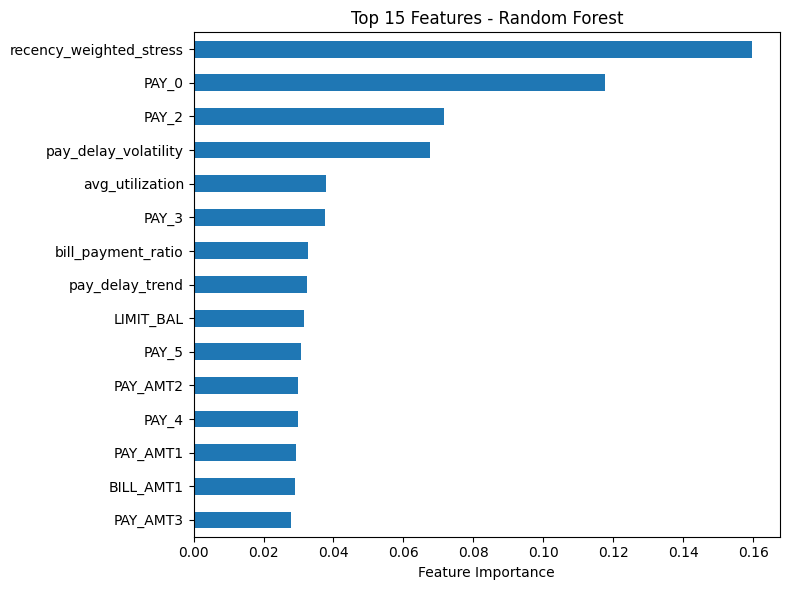

,0
recency_weighted_stress,0.159702
PAY_0,0.117576
PAY_2,0.071711
pay_delay_volatility,0.067472
avg_utilization,0.037747
PAY_3,0.037448
bill_payment_ratio,0.032772
pay_delay_trend,0.032554
LIMIT_BAL,0.031536
PAY_5,0.030592


In [ ]:
rf_importance = (
    pd.Series(
        rf_search.best_estimator_.feature_importances_,
        index=features
    )
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,6))

rf_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Features - Random Forest")
plt.xlabel("Feature Importance")
plt.tight_layout()

plt.show()

display(rf_importance.head(15))

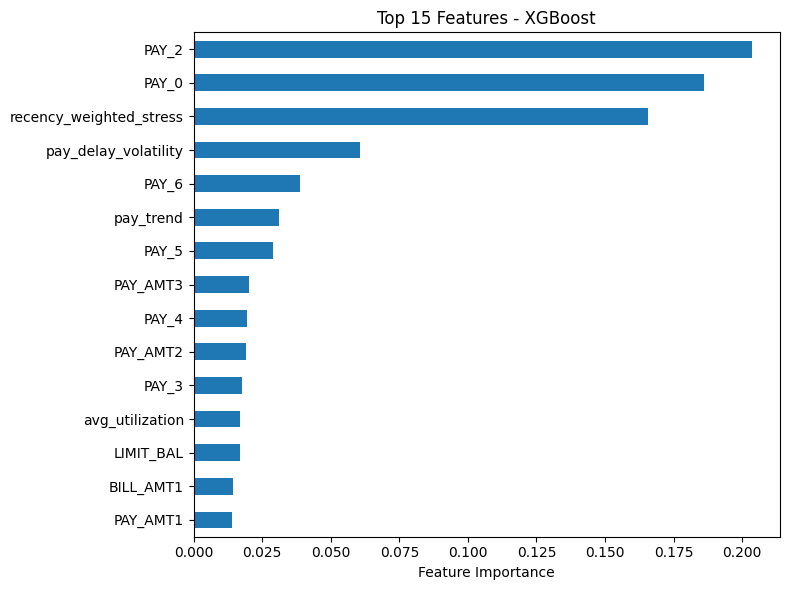

,0
PAY_2,0.203610
PAY_0,0.186159
recency_weighted_stress,0.165776
pay_delay_volatility,0.060586
PAY_6,0.038627
pay_trend,0.031101
PAY_5,0.028919
PAY_AMT3,0.020263
PAY_4,0.019344
PAY_AMT2,0.019087


In [ ]:
xgb_importance = (
    pd.Series(
        xgb_search.best_estimator_.feature_importances_,
        index=features
    )
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,6))

xgb_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Features - XGBoost")
plt.xlabel("Feature Importance")
plt.tight_layout()

plt.show()

display(xgb_importance.head(15))

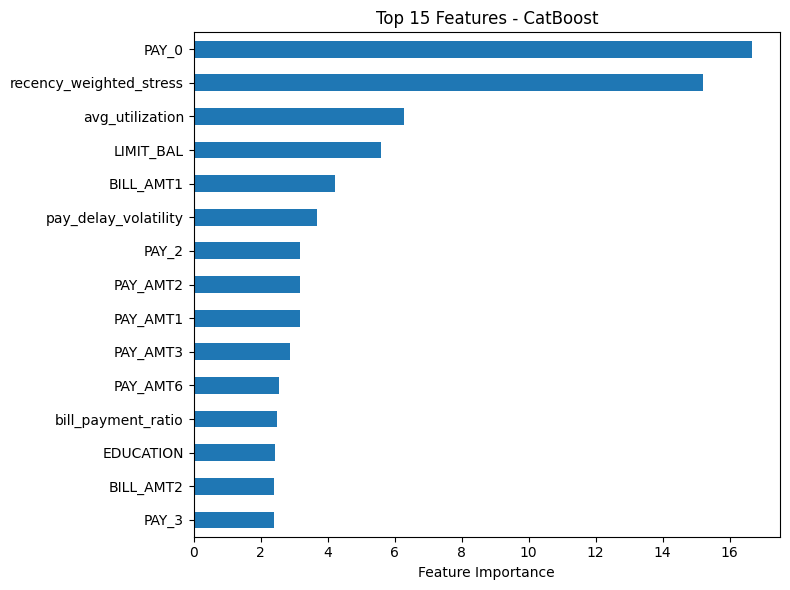

,0
PAY_0,16.667844
recency_weighted_stress,15.201088
avg_utilization,6.278953
LIMIT_BAL,5.604198
BILL_AMT1,4.206827
pay_delay_volatility,3.672605
PAY_2,3.190390
PAY_AMT2,3.182827
PAY_AMT1,3.162207
PAY_AMT3,2.884891


Top Features Across All Tree-Based Models


,Random Forest,XGBoost,CatBoost,Average Importance
PAY_0,0.117576,0.186159,16.667844,5.657193
recency_weighted_stress,0.159702,0.165776,15.201088,5.175522
avg_utilization,0.037747,0.017074,6.278953,2.111258
LIMIT_BAL,0.031536,0.016768,5.604198,1.884168
BILL_AMT1,0.029034,0.014257,4.206827,1.416706
pay_delay_volatility,0.067472,0.060586,3.672605,1.266888
PAY_2,0.071711,0.203610,3.190390,1.155237
PAY_AMT2,0.029989,0.019087,3.182827,1.077301
PAY_AMT1,0.029191,0.013868,3.162207,1.068422
PAY_AMT3,0.027891,0.020263,2.884891,0.977682


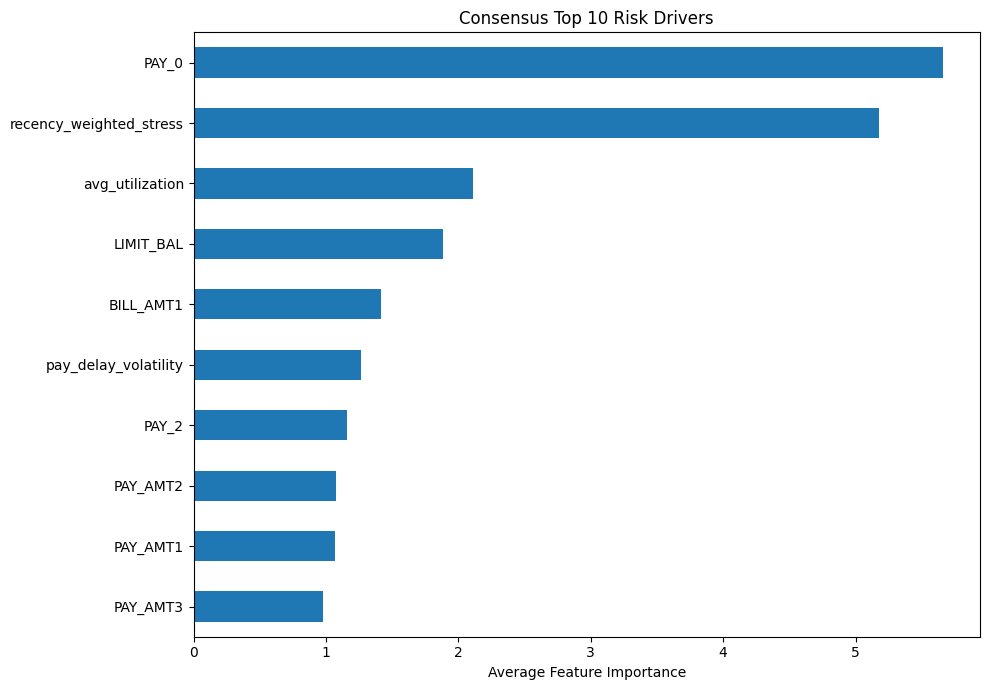

In [ ]:
cat_importance = (
    pd.Series(
        cat_search.best_estimator_.feature_importances_,
        index=features
    )
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,6))

cat_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Features - CatBoost")
plt.xlabel("Feature Importance")
plt.tight_layout()

plt.show()

display(cat_importance.head(15))

importance_df = pd.DataFrame({
    "Random Forest": rf_importance,
    "XGBoost": xgb_importance,
    "CatBoost": cat_importance
}).fillna(0)

importance_df["Average Importance"] = importance_df.mean(axis=1)

importance_df = importance_df.sort_values(
    "Average Importance",
    ascending=False
)

print("=" * 80)
print("Top Features Across All Tree-Based Models")
print("=" * 80)

display(importance_df.head(15))

plt.figure(figsize=(10,7))

importance_df.head(10)["Average Importance"]\
    .sort_values()\
    .plot(kind="barh")

plt.title("Consensus Top 10 Risk Drivers")
plt.xlabel("Average Feature Importance")

plt.tight_layout()
plt.show()

In [ ]:
val_results = X_val.copy()

val_results["True_Default"] = y_val.values

val_results["Logistic_Prob"] = log_val_probs
val_results["RandomForest_Prob"] = rf_val_probs
val_results["XGBoost_Prob"] = xgb_val_probs
val_results["CatBoost_Prob"] = cat_val_probs

save_path = "/content/drive/MyDrive/Credit_Risk_Project/data/validation_predictions.csv"

val_results.to_csv(
    save_path,
    index=False
)

print("Validation predictions saved to:")
print(save_path)

Validation predictions saved to:
/content/drive/MyDrive/Credit_Risk_Project/data/validation_predictions.csv


In [ ]:
import os

os.makedirs(
    "/content/drive/MyDrive/Credit_Risk_Project/results",
    exist_ok=True
)

results.to_csv(
    "/content/drive/MyDrive/Credit_Risk_Project/results/model_comparison.csv",
    index=False
)

importance_df.to_csv(
    "/content/drive/MyDrive/Credit_Risk_Project/results/feature_importance.csv"
)

print("Results saved successfully.")

Results saved successfully.


In [ ]:
import joblib

model_lookup = {
    "Logistic Regression": log_calibrated,
    "Random Forest": rf_calibrated,
    "XGBoost": xgb_calibrated,
    "CatBoost": cat_calibrated
}

best_model = model_lookup[best_model_name]

os.makedirs(
    "/content/drive/MyDrive/Credit_Risk_Project/models",
    exist_ok=True
)

model_path = (
    f"/content/drive/MyDrive/Credit_Risk_Project/models/"
    f"{best_model_name.lower().replace(' ','_')}.pkl"
)

joblib.dump(
    best_model,
    model_path
)

print("="*70)
print("Best model:", best_model_name)
print("Saved to:")
print(model_path)
print("="*70)

Best model: XGBoost
Saved to:
/content/drive/MyDrive/Credit_Risk_Project/models/xgboost.pkl


In [61]:
import os
import pandas as pd

# Create results folder
os.makedirs(
    "/content/drive/MyDrive/Credit_Risk_Project/results",
    exist_ok=True
)

# Get validation ROC-AUC of best model
best_auc = results.loc[
    results["Model"] == best_model_name,
    "Validation ROC-AUC"
].iloc[0]

# Save deployment metadata
deployment_metadata = pd.DataFrame({
    "Parameter": [
        "Best_Model",
        "Validation_ROC_AUC",
        "F1_Optimal_Threshold",
        "Cost_Optimal_Threshold"
    ],
    "Value": [
        best_model_name,
        best_auc,
        optimal_threshold,
        best_cost_threshold
    ]
})

metadata_path = (
    "/content/drive/MyDrive/Credit_Risk_Project/results/deployment_metadata.csv"
)

deployment_metadata.to_csv(
    metadata_path,
    index=False
)

print("=" * 80)
print("Deployment metadata saved successfully.")
print("=" * 80)

display(deployment_metadata)

Deployment metadata saved successfully.


,Parameter,Value
0,Best_Model,XGBoost
1,Validation_ROC_AUC,0.782307
2,F1_Optimal_Threshold,0.218628
3,Cost_Optimal_Threshold,0.1
